
Evaluating: GPT-5.6 Sol
Variant: before

Evaluating: GPT-5.6 Sol
Variant: after
Skipping unchanged response: Blurry_city.jpg
Skipping unchanged response: camouflaged_animal.jpg
Skipping unchanged response: crowded_market.jpg
Skipping unchanged response: cyclist.jpg
Skipping unchanged response: dark_light_man.jpg
Skipping unchanged response: distant_road_sign.jpg
Skipping unchanged response: insect.jpg
Skipping unchanged response: night_traffic_blur.jpg
Skipping unchanged response: rain_window_reflection.jpg
Skipping unchanged response: smoke_ships.jpg

Evaluating: GPT-5.6 Terra
Variant: before
Skipping unchanged response: Blurry_city.jpg
Skipping unchanged response: camouflaged_animal.jpg
Skipping unchanged response: crowded_market.jpg
Skipping unchanged response: cyclist.jpg
Skipping unchanged response: dark_light_man.jpg
Skipping unchanged response: distant_road_sign.jpg
Skipping unchanged response: insect.jpg
Skipping unchanged response: night_traffic_blur.jpg
Skipping unchanged re

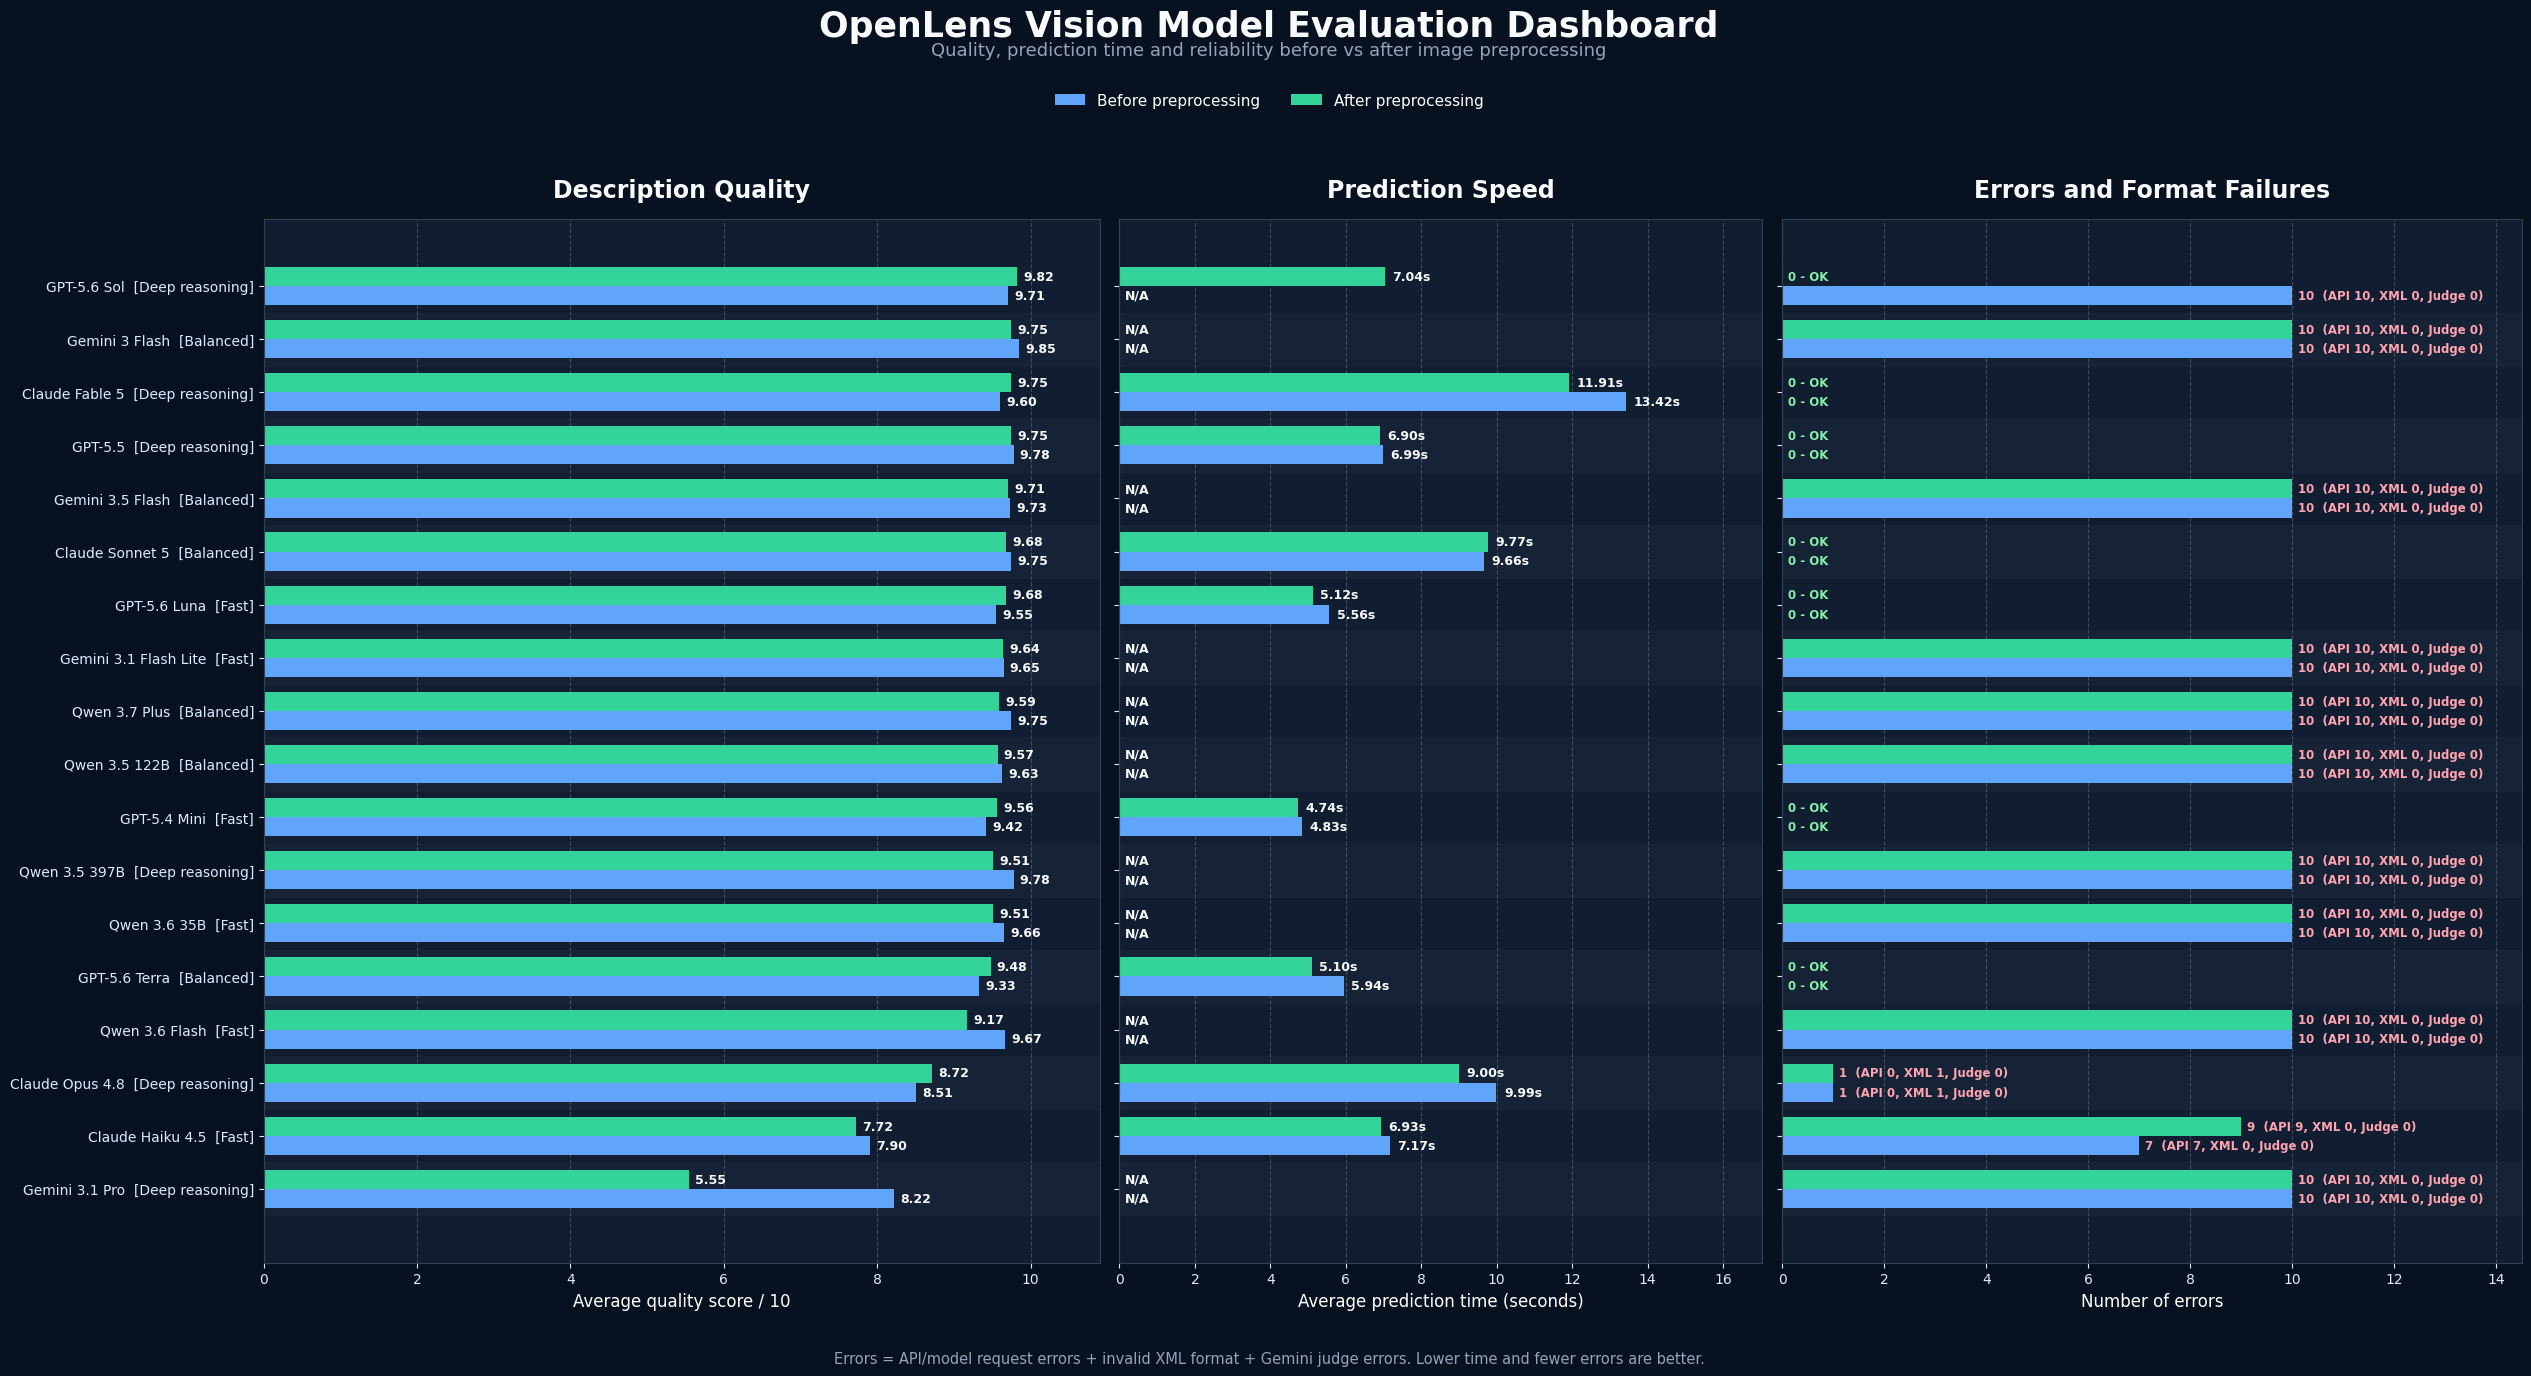

Dashboard saved to: C:\Users\ROG\openlens\Model\ModelEvaluation\model_evaluation_dashboard.png

FINAL MODEL SELECTION
Fast: GPT-5.4 Mini
Balanced / Normal: GPT-5.6 Terra
Deep reasoning: GPT-5.6 Sol


In [4]:
# SCROLL DOWN FOR THE RESULTS!

'''
The main idea of this program is ranking every model.

Gemini 3.5 Flash evaluates the heading and description
generated by every model.

The evaluation compares results before and after image
preprocessing and selects the best model for three categories:

- fast
- balanced
- deep reasoning
'''

from pathlib import Path
from getpass import getpass
from concurrent.futures import ThreadPoolExecutor, as_completed

import base64
import hashlib
import json
import mimetypes
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
import requests


API_KEY = getpass("OpenRouter API key: ")

# One fixed model evaluates every description
JUDGE_MODEL = "google/gemma-4-26b-a4b-it:free"
MAX_WORKERS = 2

RESULTS_FOLDER = Path(
    "PreprocessingModelResults"
)

DATASET_FOLDER = Path(
    "../ImageDataset"
)

# New filenames prevent old scores from being reused
EVALUATIONS_FILE = Path(
    "description_evaluations_v2.csv"
)

SUMMARY_FILE = Path(
    "model_quality_summary_v2.csv"
)

# None evaluates every image from the dataset
MAX_DESCRIPTIONS_PER_MODEL = None


MODELS = {
    "GPT-5.6 Sol": {
        "file": "gpt_5_6_sol",
        "tier": "Deep reasoning",
    },
    "GPT-5.6 Terra": {
        "file": "gpt_5_6_terra",
        "tier": "Balanced",
    },
    "GPT-5.6 Luna": {
        "file": "gpt_5_6_luna",
        "tier": "Fast",
    },
    "GPT-5.5": {
        "file": "gpt_5_5",
        "tier": "Deep reasoning",
    },
    "GPT-5.4 Mini": {
        "file": "gpt_5_4_mini",
        "tier": "Fast",
    },
    "Claude Sonnet 5": {
        "file": "claude_sonnet_5",
        "tier": "Balanced",
    },
    "Claude Fable 5": {
        "file": "claude_fable_5",
        "tier": "Deep reasoning",
    },
    "Claude Opus 4.8": {
        "file": "claude_opus_4_8",
        "tier": "Deep reasoning",
    },
    "Claude Haiku 4.5": {
        "file": "claude_haiku_4_5",
        "tier": "Fast",
    },
    "Gemini 3.5 Flash": {
        "file": "gemini_3_5_flash",
        "tier": "Balanced",
    },
    "Gemini 3.1 Pro": {
        "file": "gemini_3_1_pro",
        "tier": "Deep reasoning",
    },
    "Gemini 3.1 Flash Lite": {
        "file": "gemini_3_1_flash_lite",
        "tier": "Fast",
    },
    "Gemini 3 Flash": {
        "file": "gemini_3_flash",
        "tier": "Balanced",
    },
    "Qwen 3.7 Plus": {
        "file": "qwen_3_7_plus",
        "tier": "Balanced",
    },
    "Qwen 3.6 Flash": {
        "file": "qwen_3_6_flash",
        "tier": "Fast",
    },
    "Qwen 3.6 35B": {
        "file": "qwen_3_6_35b",
        "tier": "Fast",
    },
    "Qwen 3.5 397B": {
        "file": "qwen_3_5_397b",
        "tier": "Deep reasoning",
    },
    "Qwen 3.5 122B": {
        "file": "qwen_3_5_122b",
        "tier": "Balanced",
    },
}


JUDGE_PROMPT = """
Strictly evaluate the proposed heading and description using
the attached image.

The identity of the model that generated the answer is hidden.
Judge only factual accuracy and writing quality.

Use scores from 0.0 to 10.0.
Decimal scores such as 7.4 or 8.7 are encouraged.

Use this strict scoring scale:

10 = exceptional and almost perfect
9 = excellent, with one very small weakness
8 = good, but some useful details are missing
7 = generally correct, with noticeable weaknesses
6 = acceptable, but incomplete or imprecise
5 = average, with several problems
4 = important details are wrong or missing
3 = mostly incorrect
2 = seriously incorrect
1 = almost completely incorrect
0 = completely incorrect

Do not automatically give 10 when an answer is simply correct.
Consider missing details, vague wording, unnecessary claims,
small inaccuracies and unsupported information.

Evaluation criteria:

1. subject_accuracy
Is the main subject identified precisely and correctly?

2. visual_details
Are useful colors, materials, shapes, context and visible text
included and correct?

3. no_hallucinations
Does the answer avoid invented, incorrect or unsupported
information?

4. clarity
Is the answer concise, factual, grammatical and easy to
understand?

5. heading_quality
Is the heading short, specific and accurate?

Return only valid JSON using this exact format:

{{
  "subject_accuracy": 0.0,
  "visual_details": 0.0,
  "no_hallucinations": 0.0,
  "clarity": 0.0,
  "heading_quality": 0.0,
  "reason": "Short explanation of the strengths and weaknesses"
}}

Candidate heading:
{heading}

Candidate description:
{description}
"""


def encode_original_image(image_path):
    image_bytes = image_path.read_bytes()

    mime_type = (
        mimetypes.guess_type(image_path.name)[0]
        or "image/jpeg"
    )

    image_b64 = base64.b64encode(
        image_bytes
    ).decode("utf-8")

    return mime_type, image_b64


def clamp_score(value):
    return min(
        max(float(value), 0.0),
        10.0,
    )


def response_fingerprint(heading, description):
    response_text = f"{heading}\0{description}"
    return hashlib.sha256(
        response_text.encode("utf-8")
    ).hexdigest()


def evaluate_description(
    image_path,
    heading,
    description,
):
    mime_type, image_b64 = encode_original_image(
        image_path
    )

    prompt = JUDGE_PROMPT.format(
        heading=heading,
        description=description,
    )

    payload = {
        "model": JUDGE_MODEL,
        "temperature": 0,
        "max_tokens": 300,
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": prompt,
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": (
                                f"data:{mime_type};base64,"
                                + image_b64
                            )
                        },
                    },
                ],
            }
        ],
    }

    response = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {API_KEY}",
            "Content-Type": "application/json",
        },
        json=payload,
        timeout=180,
    )

    response.raise_for_status()

    content = response.json()[
        "choices"
    ][0]["message"]["content"]

    json_match = re.search(
        r"\{.*\}",
        content,
        re.DOTALL,
    )

    if not json_match:
        raise ValueError(
            "Evaluator did not return valid JSON: "
            f"{content}"
        )

    scores = json.loads(
        json_match.group(0)
    )

    subject_accuracy = clamp_score(
        scores["subject_accuracy"]
    )

    visual_details = clamp_score(
        scores["visual_details"]
    )

    no_hallucinations = clamp_score(
        scores["no_hallucinations"]
    )

    clarity = clamp_score(
        scores["clarity"]
    )

    heading_quality = clamp_score(
        scores["heading_quality"]
    )

    # Weighted final score from 0 to 10
    total_score = (
        subject_accuracy * 0.35
        + visual_details * 0.20
        + no_hallucinations * 0.25
        + clarity * 0.10
        + heading_quality * 0.10
    )

    return {
        "subject_accuracy": subject_accuracy,
        "visual_details": visual_details,
        "no_hallucinations": no_hallinations
        if False
        else no_hallucinations,
        "clarity": clarity,
        "heading_quality": heading_quality,
        "total_score": round(
            total_score,
            2,
        ),
        "evaluation_reason": scores.get(
            "reason",
            "",
        ),
    }


evaluation_results = []

if EVALUATIONS_FILE.exists():
    evaluation_results = pd.read_csv(
        EVALUATIONS_FILE
    ).to_dict("records")


completed_evaluations = {
    (
        result["model"],
        result["variant"],
        result["image_path"],
        result.get("response_fingerprint", ""),
    )
    for result in evaluation_results
    if result.get("evaluation_status") == "success"
}


generation_statistics = []
current_generation_keys = set()


for model_name, model_data in MODELS.items():
    for variant in ["before", "after"]:
        csv_path = RESULTS_FOLDER / (
            f"submission_{model_data['file']}_{variant}.csv"
        )

        if not csv_path.exists():
            print(
                f"Missing file: {csv_path}"
            )
            continue

        dataframe = pd.read_csv(
            csv_path
        )

        for image_path_text in dataframe[
            "image_path"
        ].astype(str):
            current_generation_keys.add(
                (
                    model_name,
                    variant,
                    image_path_text,
                )
            )

        success_mask = dataframe[
            "status"
        ].eq("success")

        if "format_ok" in dataframe.columns:
            format_ok_mask = dataframe[
                "format_ok"
            ].astype(str).str.lower().eq("true")
        else:
            format_ok_mask = pd.Series(
                False,
                index=dataframe.index,
            )

        successful_times = pd.to_numeric(
            dataframe.loc[
                success_mask,
                "response_time_seconds",
            ],
            errors="coerce",
        )

        generation_statistics.append(
            {
                "model": model_name,
                "tier": model_data["tier"],
                "variant": variant,
                "total_requests": len(dataframe),
                "successful_generations": int(
                    success_mask.sum()
                ),
                "generation_errors": int(
                    (~success_mask).sum()
                ),
                "format_errors": int(
                    (
                        success_mask
                        & ~format_ok_mask
                    ).sum()
                ),
                "average_response_time": (
                    successful_times.mean()
                ),
            }
        )

        dataframe = dataframe[
            success_mask
        ].copy()

        if MAX_DESCRIPTIONS_PER_MODEL is not None:
            dataframe = dataframe.head(
                MAX_DESCRIPTIONS_PER_MODEL
            )

        print()
        print("=" * 70)
        print(
            f"Evaluating: {model_name}"
        )
        print(
            f"Variant: {variant}"
        )
        print("=" * 70)

        pending_evaluations = []

        for row_index, row in dataframe.iterrows():
            image_path_text = str(
                row["image_path"]
            )

            heading = (
                ""
                if pd.isna(row["heading"])
                else str(row["heading"])
            )

            description = (
                ""
                if pd.isna(row["description"])
                else str(row["description"])
            )

            fingerprint = response_fingerprint(
                heading,
                description,
            )

            evaluation_key = (
                model_name,
                variant,
                image_path_text,
                fingerprint,
            )

            if evaluation_key in completed_evaluations:
                print(
                    "Skipping unchanged response: "
                    f"{Path(image_path_text).name}"
                )
                continue

            image_path = Path(
                image_path_text
            )

            if not image_path.exists():
                image_path = (
                    DATASET_FOLDER
                    / Path(image_path_text).name
                )

            pending_evaluations.append(
                {
                    "evaluation_key": evaluation_key,
                    "response_fingerprint": fingerprint,
                    "image_path_text": image_path_text,
                    "image_path": image_path,
                    "heading": heading,
                    "description": description,
                    "generation_response_time": row[
                        "response_time_seconds"
                    ],
                }
            )

        def evaluate_pending(item):
            try:
                scores = evaluate_description(
                    item["image_path"],
                    item["heading"],
                    item["description"],
                )

                evaluation_status = "success"
                evaluation_error = ""

            except Exception as error:
                scores = {
                    "subject_accuracy": None,
                    "visual_details": None,
                    "no_hallucinations": None,
                    "clarity": None,
                    "heading_quality": None,
                    "total_score": None,
                    "evaluation_reason": "",
                }

                evaluation_status = "error"
                evaluation_error = str(error)

            return {
                "model": model_name,
                "tier": model_data["tier"],
                "variant": variant,
                "image_path": item["image_path_text"],
                "response_fingerprint": item["response_fingerprint"],
                "heading": item["heading"],
                "description": item["description"],
                "generation_response_time": item[
                    "generation_response_time"
                ],
                "evaluation_status": evaluation_status,
                "evaluation_error": evaluation_error,
                **scores,
            }

        if pending_evaluations:
            worker_count = min(
                MAX_WORKERS,
                len(pending_evaluations),
            )

            with ThreadPoolExecutor(
                max_workers=worker_count
            ) as executor:
                future_to_item = {
                    executor.submit(
                        evaluate_pending,
                        item,
                    ): item
                    for item in pending_evaluations
                }

                for completed_index, future in enumerate(
                    as_completed(future_to_item),
                    start=1,
                ):
                    item = future_to_item[future]
                    result = future.result()

                    evaluation_results.append(result)

                    if result["evaluation_status"] == "success":
                        completed_evaluations.add(
                            item["evaluation_key"]
                        )

                    print(
                        f"[{completed_index}/"
                        f"{len(pending_evaluations)}] "
                        f"Evaluated: {item['image_path'].name} - "
                        f"{result['evaluation_status']}"
                    )

                    if result["evaluation_status"] == "error":
                        print(
                            f"ERROR: {result['evaluation_error']}"
                        )

                    pd.DataFrame(
                        evaluation_results
                    ).to_csv(
                        EVALUATIONS_FILE,
                        index=False,
                        encoding="utf-8-sig",
                    )


evaluations_df = pd.DataFrame(
    evaluation_results
)


if evaluations_df.empty:
    evaluations_df = pd.DataFrame(
        columns=[
            "model",
            "tier",
            "variant",
            "image_path",
            "evaluation_status",
            "total_score",
            "subject_accuracy",
            "visual_details",
            "no_hallucinations",
            "clarity",
            "heading_quality",
        ]
    )
else:
    current_rows = evaluations_df.apply(
        lambda row: (
            row["model"],
            row["variant"],
            str(row["image_path"]),
        ) in current_generation_keys,
        axis=1,
    )

    evaluations_df = evaluations_df[
        current_rows
    ].copy()

    evaluations_df = evaluations_df.drop_duplicates(
        subset=[
            "model",
            "variant",
            "image_path",
        ],
        keep="last",
    )


successful_requests = evaluations_df[
    "evaluation_status"
].eq("success").sum()

failed_requests = evaluations_df[
    "evaluation_status"
].eq("error").sum()

print()
print("JUDGE REQUEST SUMMARY")
print("=" * 45)
print(
    f"Successful: {successful_requests}"
)
print(
    f"Failed: {failed_requests}"
)
print(
    f"Total: {len(evaluations_df)}"
)


successful_evaluations = evaluations_df[
    evaluations_df[
        "evaluation_status"
    ].eq("success")
].copy()


quality_columns = [
    "model",
    "tier",
    "variant",
    "quality_score",
    "subject_accuracy",
    "visual_details",
    "no_hallucinations",
    "clarity",
    "heading_quality",
    "evaluated_descriptions",
]


if successful_evaluations.empty:
    quality_summary = pd.DataFrame(
        columns=quality_columns
    )
else:
    quality_summary = (
        successful_evaluations
        .groupby(
            [
                "model",
                "tier",
                "variant",
            ],
            as_index=False,
        )
        .agg(
            quality_score=(
                "total_score",
                "mean",
            ),
            subject_accuracy=(
                "subject_accuracy",
                "mean",
            ),
            visual_details=(
                "visual_details",
                "mean",
            ),
            no_hallucinations=(
                "no_hallucinations",
                "mean",
            ),
            clarity=(
                "clarity",
                "mean",
            ),
            heading_quality=(
                "heading_quality",
                "mean",
            ),
            evaluated_descriptions=(
                "total_score",
                "count",
            ),
        )
    )


if evaluations_df.empty:
    evaluator_summary = pd.DataFrame(
        columns=[
            "model",
            "tier",
            "variant",
            "evaluator_requests",
            "evaluator_errors",
        ]
    )
else:
    evaluator_summary = (
        evaluations_df
        .groupby(
            [
                "model",
                "tier",
                "variant",
            ],
            as_index=False,
        )
        .agg(
            evaluator_requests=(
                "evaluation_status",
                "size",
            ),
            evaluator_errors=(
                "evaluation_status",
                lambda values: (
                    ~values.eq("success")
                ).sum(),
            ),
        )
    )


generation_summary = pd.DataFrame(
    generation_statistics
)

summary = generation_summary.merge(
    quality_summary,
    on=[
        "model",
        "tier",
        "variant",
    ],
    how="left",
)

summary = summary.merge(
    evaluator_summary,
    on=[
        "model",
        "tier",
        "variant",
    ],
    how="left",
)

count_columns = [
    "evaluator_requests",
    "evaluator_errors",
    "evaluated_descriptions",
]

for column in count_columns:
    summary[column] = summary[
        column
    ].fillna(0).astype(int)

summary["total_errors"] = (
    summary["generation_errors"]
    + summary["format_errors"]
    + summary["evaluator_errors"]
)

summary["error_status"] = summary[
    "total_errors"
].apply(
    lambda value: (
        "OK - no errors"
        if value == 0
        else f"{value} error(s)"
    )
)

score_columns = [
    "quality_score",
    "subject_accuracy",
    "visual_details",
    "no_hallucinations",
    "clarity",
    "heading_quality",
    "average_response_time",
]

summary[score_columns] = summary[
    score_columns
].round(2)

summary.to_csv(
    SUMMARY_FILE,
    index=False,
    encoding="utf-8-sig",
)


print()
print("MODEL ERROR AND SPEED REPORT")
print("=" * 70)

for model_name in MODELS:
    model_rows = summary[
        summary["model"].eq(model_name)
    ]

    for variant in ["before", "after"]:
        row = model_rows[
            model_rows["variant"].eq(variant)
        ]

        if row.empty:
            continue

        row = row.iloc[0]
        print(
            f"{model_name} | {variant}: "
            f"{row['average_response_time']:.2f}s | "
            f"{row['error_status']} "
            f"(API={row['generation_errors']}, "
            f"XML={row['format_errors']}, "
            f"Judge={row['evaluator_errors']})"
        )


def create_evaluation_dashboard(summary_data):
    metrics = [
        "quality_score",
        "average_response_time",
        "total_errors",
        "generation_errors",
        "format_errors",
        "evaluator_errors",
    ]

    before = summary_data[
        summary_data["variant"].eq("before")
    ][
        ["model"] + metrics
    ].rename(
        columns={
            metric: f"before_{metric}"
            for metric in metrics
        }
    )

    after = summary_data[
        summary_data["variant"].eq("after")
    ][
        ["model", "tier"] + metrics
    ].rename(
        columns={
            metric: f"after_{metric}"
            for metric in metrics
        }
    )

    comparison = after.merge(
        before,
        on="model",
        how="inner",
    )

    if comparison.empty:
        raise ValueError(
            "No models have both before and after results."
        )

    comparison["sort_score"] = comparison[
        "after_quality_score"
    ].fillna(-1)

    comparison = comparison.sort_values(
        "sort_score",
        ascending=True,
    ).reset_index(drop=True)

    labels = [
        f"{model}  [{tier}]"
        for model, tier in zip(
            comparison["model"],
            comparison["tier"],
        )
    ]

    positions = list(
        range(len(comparison))
    )

    bar_height = 0.36
    before_positions = [
        position - bar_height / 2
        for position in positions
    ]
    after_positions = [
        position + bar_height / 2
        for position in positions
    ]

    before_color = "#60a5fa"
    after_color = "#34d399"
    background = "#08111f"
    panel_color = "#111d31"
    text_color = "#f8fafc"

    plt.style.use("dark_background")

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(26, 14),
        gridspec_kw={
            "width_ratios": [1.30, 1.0, 1.15]
        },
    )

    figure.patch.set_facecolor(background)

    for axis in axes:
        axis.set_facecolor(panel_color)
        axis.grid(
            axis="x",
            linestyle="--",
            alpha=0.20,
        )
        axis.set_axisbelow(True)
        axis.tick_params(colors="#dbeafe")

        for position in positions:
            if position % 2 == 0:
                axis.axhspan(
                    position - 0.5,
                    position + 0.5,
                    color="white",
                    alpha=0.025,
                )

        for spine in axis.spines.values():
            spine.set_color("#334155")

    quality_before = comparison[
        "before_quality_score"
    ]
    quality_after = comparison[
        "after_quality_score"
    ]

    quality_before_bars = axes[0].barh(
        before_positions,
        quality_before.fillna(0),
        height=bar_height,
        color=before_color,
        label="Before preprocessing",
    )

    quality_after_bars = axes[0].barh(
        after_positions,
        quality_after.fillna(0),
        height=bar_height,
        color=after_color,
        label="After preprocessing",
    )

    axes[0].set_yticks(positions)
    axes[0].set_yticklabels(
        labels,
        fontsize=10,
    )
    axes[0].set_xlim(0, 10.9)
    axes[0].set_xlabel(
        "Average quality score / 10",
        fontsize=12,
    )
    axes[0].set_title(
        "Description Quality",
        fontsize=17,
        fontweight="bold",
        color=text_color,
        pad=16,
    )

    for bars, values in [
        (quality_before_bars, quality_before),
        (quality_after_bars, quality_after),
    ]:
        for bar, value in zip(bars, values):
            label = (
                "N/A"
                if pd.isna(value)
                else f"{value:.2f}"
            )
            x_value = (
                0.12
                if pd.isna(value)
                else value + 0.08
            )
            axes[0].text(
                x_value,
                bar.get_y() + bar.get_height() / 2,
                label,
                va="center",
                fontsize=9,
                fontweight="bold",
                color=text_color,
            )

    time_before = comparison[
        "before_average_response_time"
    ]
    time_after = comparison[
        "after_average_response_time"
    ]

    time_before_bars = axes[1].barh(
        before_positions,
        time_before.fillna(0),
        height=bar_height,
        color=before_color,
    )
    time_after_bars = axes[1].barh(
        after_positions,
        time_after.fillna(0),
        height=bar_height,
        color=after_color,
    )

    axes[1].set_yticks(positions)
    axes[1].set_yticklabels([])

    maximum_time = max(
        time_before.max(skipna=True),
        time_after.max(skipna=True),
    )
    if pd.isna(maximum_time) or maximum_time <= 0:
        maximum_time = 1

    axes[1].set_xlim(0, maximum_time * 1.27)
    axes[1].set_xlabel(
        "Average prediction time (seconds)",
        fontsize=12,
    )
    axes[1].set_title(
        "Prediction Speed",
        fontsize=17,
        fontweight="bold",
        color=text_color,
        pad=16,
    )

    for bars, values in [
        (time_before_bars, time_before),
        (time_after_bars, time_after),
    ]:
        for bar, value in zip(bars, values):
            label = (
                "N/A"
                if pd.isna(value)
                else f"{value:.2f}s"
            )
            x_value = (
                maximum_time * 0.01
                if pd.isna(value)
                else value + maximum_time * 0.015
            )
            axes[1].text(
                x_value,
                bar.get_y() + bar.get_height() / 2,
                label,
                va="center",
                fontsize=9,
                fontweight="bold",
                color=text_color,
            )

    errors_before = comparison[
        "before_total_errors"
    ].astype(int)
    errors_after = comparison[
        "after_total_errors"
    ].astype(int)

    error_before_bars = axes[2].barh(
        before_positions,
        errors_before,
        height=bar_height,
        color=before_color,
    )
    error_after_bars = axes[2].barh(
        after_positions,
        errors_after,
        height=bar_height,
        color=after_color,
    )

    axes[2].set_yticks(positions)
    axes[2].set_yticklabels([])

    maximum_errors = max(
        errors_before.max(),
        errors_after.max(),
        1,
    )
    axes[2].set_xlim(0, maximum_errors + 4.5)
    axes[2].set_xlabel(
        "Number of errors",
        fontsize=12,
    )
    axes[2].set_title(
        "Errors and Format Failures",
        fontsize=17,
        fontweight="bold",
        color=text_color,
        pad=16,
    )

    def add_error_labels(axis, bars, prefix):
        for bar, (_, row) in zip(
            bars,
            comparison.iterrows(),
        ):
            total = int(
                row[f"{prefix}_total_errors"]
            )
            api_errors = int(
                row[f"{prefix}_generation_errors"]
            )
            xml_errors = int(
                row[f"{prefix}_format_errors"]
            )
            judge_errors = int(
                row[f"{prefix}_evaluator_errors"]
            )

            if total == 0:
                label = "0 - OK"
                label_color = "#86efac"
            else:
                label = (
                    f"{total}  "
                    f"(API {api_errors}, "
                    f"XML {xml_errors}, "
                    f"Judge {judge_errors})"
                )
                label_color = "#fda4af"

            axis.text(
                total + 0.12,
                bar.get_y() + bar.get_height() / 2,
                label,
                va="center",
                fontsize=8.5,
                fontweight="bold",
                color=label_color,
            )

    add_error_labels(
        axes[2],
        error_before_bars,
        "before",
    )
    add_error_labels(
        axes[2],
        error_after_bars,
        "after",
    )

    figure.suptitle(
        "OpenLens Vision Model Evaluation Dashboard",
        fontsize=25,
        fontweight="bold",
        color=text_color,
        y=0.985,
    )

    figure.text(
        0.5,
        0.952,
        (
            "Quality, prediction time and reliability "
            "before vs after image preprocessing"
        ),
        ha="center",
        fontsize=13,
        color="#94a3b8",
    )

    figure.legend(
        handles=[
            quality_before_bars[0],
            quality_after_bars[0],
        ],
        labels=[
            "Before preprocessing",
            "After preprocessing",
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.935),
        ncol=2,
        frameon=False,
        fontsize=11,
    )

    figure.text(
        0.5,
        0.018,
        (
            "Errors = API/model request errors + invalid XML "
            "format + Gemini judge errors. Lower time and fewer "
            "errors are better."
        ),
        ha="center",
        fontsize=10.5,
        color="#94a3b8",
    )

    plt.tight_layout(
        rect=[0.01, 0.045, 0.99, 0.91]
    )

    output_file = Path(
        "model_evaluation_dashboard.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
        facecolor=figure.get_facecolor(),
    )

    plt.show()

    print(
        "Dashboard saved to: "
        f"{output_file.resolve()}"
    )


create_evaluation_dashboard(
    summary
)


# Final model selection uses results after preprocessing
selection_df = summary[
    summary["variant"].eq("after")
    & summary["quality_score"].notna()
    & summary["average_response_time"].notna()
].copy()


if selection_df.empty:
    raise ValueError(
        "No after-preprocessing results "
        "were found."
    )


minimum_time = selection_df[
    "average_response_time"
].min()

maximum_time = selection_df[
    "average_response_time"
].max()


if minimum_time == maximum_time:
    selection_df["speed_score"] = 100.0

else:
    selection_df["speed_score"] = (
        (
            maximum_time
            - selection_df[
                "average_response_time"
            ]
        )
        / (
            maximum_time
            - minimum_time
        )
        * 100
    )


selection_df["quality_percent"] = (
    selection_df["quality_score"]
    * 10
)


def calculate_selection_score(row):
    if row["tier"] == "Fast":
        return (
            row["quality_percent"] * 0.50
            + row["speed_score"] * 0.40
            + 100 * 0.10
        )

    if row["tier"] == "Balanced":
        return (
            row["quality_percent"] * 0.70
            + row["speed_score"] * 0.20
            + 100 * 0.10
        )

    return (
        row["quality_percent"] * 0.85
        + row["speed_score"] * 0.05
        + 100 * 0.10
    )


selection_df["selection_score"] = (
    selection_df.apply(
        calculate_selection_score,
        axis=1,
    )
)


recommendations = {}


for tier in [
    "Fast",
    "Balanced",
    "Deep reasoning",
]:
    tier_results = selection_df[
        selection_df["tier"].eq(tier)
    ]

    if tier_results.empty:
        recommendations[tier] = "No model"
        continue

    best_index = tier_results[
        "selection_score"
    ].idxmax()

    recommendations[tier] = (
        selection_df.loc[
            best_index,
            "model",
        ]
    )


print()
print("FINAL MODEL SELECTION")
print("=" * 45)

print(
    f"Fast: {recommendations['Fast']}"
)

print(
    "Balanced / Normal: "
    f"{recommendations['Balanced']}"
)

print(
    "Deep reasoning: "
    f"{recommendations['Deep reasoning']}"
)